# Disaster Risk and Resource Demand Estimation
## Coastal Odisha (5 Districts, 2017–2024)

Decision support system for risk informed resource allocation using
NASA POWER weather observations, environmental conditions, and
district level exposure indicators.

> Pre-positioning supplies 48 hours before flood peak reduces logistics cost ~30% and expands beneficiary reach from 5,000 to 15,000 people on the same budget.

### Notebook Map
| Cell | Section |
|------|--------|
| 1 | Imports & configuration |
| 2 | NASA POWER data loading & preprocessing |
| 3 | EDA |
| 4 | Feature engineering |
| 5 | Target construction |
| 6 | Train-test split & GBM quantile model |
| 7 | Baseline comparison |
| 8 | Forecast visualisation |
| 9 | Feature importance |
| 10 | 30-day forecast & decision-support table |
| 11 | Decision-support summary |

**Stack:** Python · scikit-learn · Matplotlib · Seaborn · Pandas · NumPy  
**Data:** NASA POWER MERRA-2 daily meteorological data for 5 coastal Odisha districts


In [13]:
import warnings, json, os
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': '#0F1117', 'axes.facecolor': '#1A1D27',
    'axes.edgecolor': '#3A3F52', 'grid.color': '#2A2D3A',
    'text.color': '#E8EAF0', 'axes.labelcolor': '#C5C8D4',
    'xtick.color': '#9599AA', 'ytick.color': '#9599AA',
    'figure.dpi': 120, 'font.family': 'DejaVu Sans',
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'legend.facecolor': '#1A1D27', 'legend.edgecolor': '#3A3F52',
    'legend.fontsize': 9,
})

ACCENT  = '#4C9EEB'
ACCENT2 = '#F5A623'
SUCCESS = '#52C17A'
DANGER  = '#E85D5D'
PURPLE  = '#A78BFA'
CYAN    = '#22D3EE'

DISTRICTS = ['Puri', 'Kendrapara', 'Jagatsinghpur', 'Bhadrak', 'Balasore']

DATA_FILES = {
    'Puri':          '/content/data/puri.csv',
    'Kendrapara':    '/content/data/Kendrapara.csv',
    'Jagatsinghpur': '/content/data/Jagatsinghpur.csv',
    'Bhadrak':       '/content/data/Bhadrak.csv',
    'Balasore':      '/content/data/Balasore.csv',
}

SPHERE_NORMS = {
    'Relief Kits': 1,
    'Dry Rations (kg)': 2.5,
    'ORS Packets': 10,
    'Tarpaulin Sheets': 0.2,
    'Medical Kits': 0.02,
}

SPHERE_THRESHOLD = 1500
ALERT_THRESHOLD  = 800


In [14]:
def load_nasa_csv(filepath, district):
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    header_end = next(
        i for i, l in enumerate(lines) if '-END HEADER-' in l)
    df = pd.read_csv(
        filepath, skiprows=header_end + 1,
        na_values=['-999', -999])
    df.columns = df.columns.str.strip()
    df['date'] = pd.to_datetime(
        df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3),
        format='%Y%j')
    df = df.rename(columns={
        'PRECTOTCORR': 'rainfall_mm',
        'RH2M':        'humidity',
        'WS2M':        'wind_speed',
        'GWETTOP':     'soil_wetness',
        'T2M':         'temperature',
    })
    df['district'] = district
    keep = ['date', 'district', 'rainfall_mm', 'humidity',
            'wind_speed', 'soil_wetness', 'temperature']
    return df[keep].dropna().reset_index(drop=True)

dfs = [load_nasa_csv(path, district)
       for district, path in DATA_FILES.items()]
data = (pd.concat(dfs, ignore_index=True)
        .sort_values(['district', 'date'])
        .reset_index(drop=True))

data['rainfall_mm']  = data['rainfall_mm'].clip(lower=0)
data['wind_speed']   = data['wind_speed'].clip(lower=0)
data['soil_wetness'] = data['soil_wetness'].clip(0, 1)

print(f'Loaded {len(data):,} rows | {data["district"].nunique()} districts')
print(f'Date range: {data["date"].min().date()} to {data["date"].max().date()}')
data.head(10)


Loaded 14,610 rows | 5 districts
Date range: 2017-01-01 to 2024-12-31


,date,district,rainfall_mm,humidity,wind_speed,soil_wetness,temperature
0,2017-01-01,Balasore,0.06,81.23,0.93,0.58,21.21
1,2017-01-02,Balasore,0.86,78.88,0.70,0.59,21.17
2,2017-01-03,Balasore,1.74,78.87,1.18,0.59,20.47
3,2017-01-04,Balasore,0.16,74.12,1.93,0.58,19.88
4,2017-01-05,Balasore,0.00,67.76,1.82,0.57,19.40
5,2017-01-06,Balasore,0.00,61.92,1.57,0.57,19.06
6,2017-01-07,Balasore,0.00,60.29,1.33,0.56,19.20
7,2017-01-08,Balasore,0.00,60.18,1.16,0.56,20.43
8,2017-01-09,Balasore,0.00,67.68,1.23,0.55,20.43
9,2017-01-10,Balasore,0.00,71.66,1.55,0.55,20.35


## Methodology Note

This project uses real NASA POWER daily weather observations for
five coastal districts of Odisha from 2017–2024.

Historical district-level relief-distribution records are not publicly
available in a form suitable for supervised machine learning.

Therefore, a transparent weather-based risk-to-resource estimation
framework is used.

Estimated resource requirements are derived from rainfall,
wind speed, soil wetness, humidity, temperature, and district-level
population scaling.

The forecasting model predicts future risk-adjusted resource
requirements rather than historical relief inventory records.

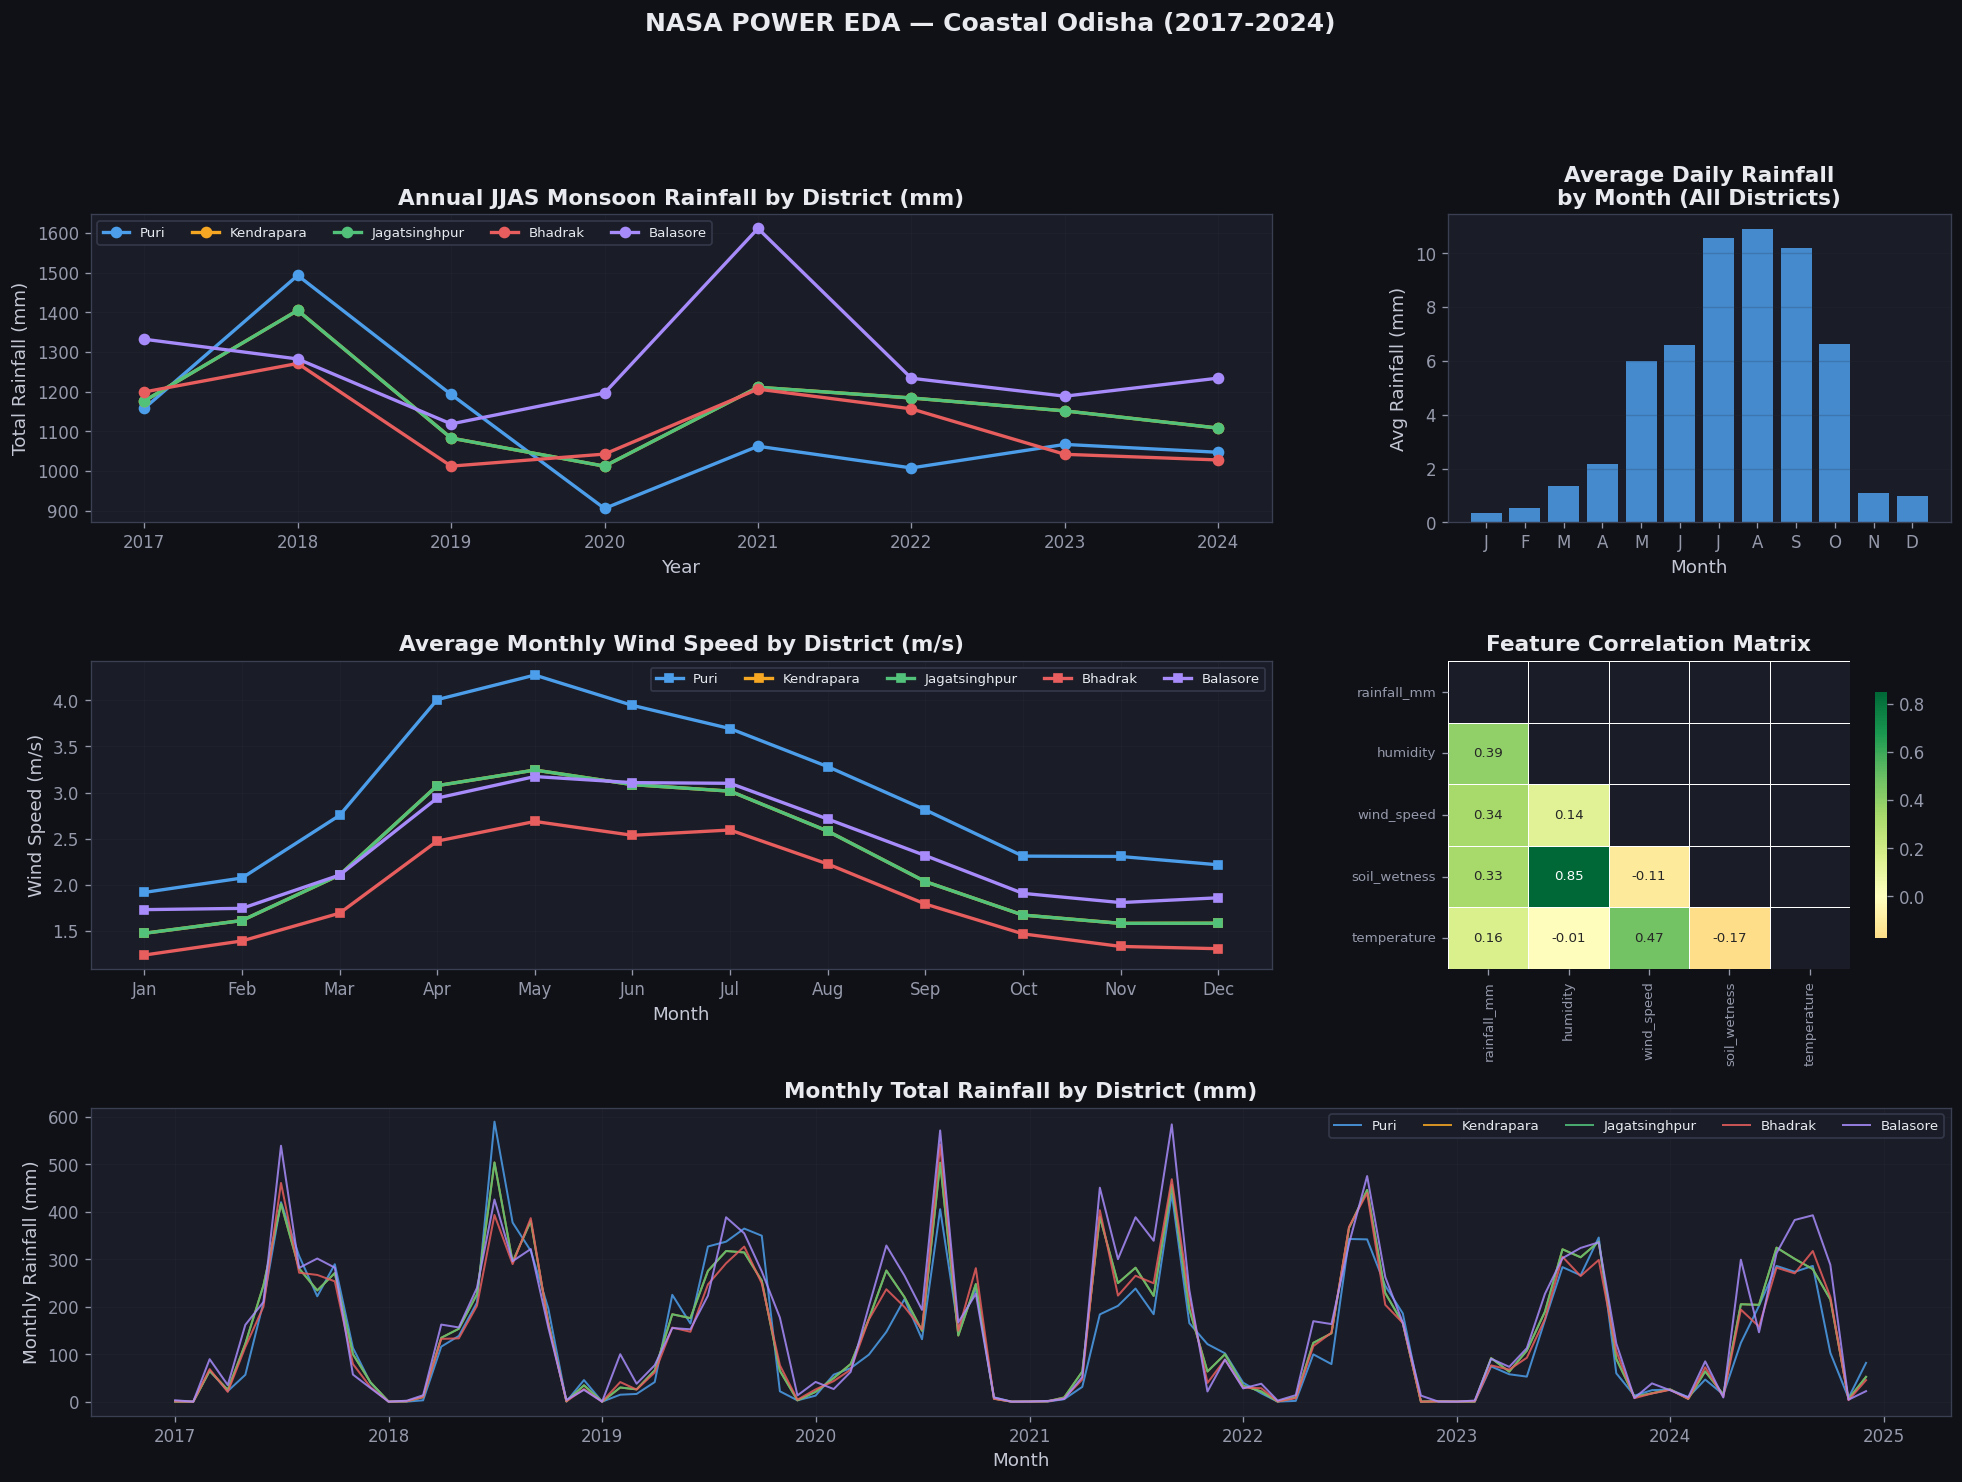

In [16]:
fig = plt.figure(figsize=(20, 13))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
colors_d = dict(zip(DISTRICTS, [ACCENT, ACCENT2, SUCCESS, DANGER, PURPLE]))

ax1 = fig.add_subplot(gs[0, :2])
monsoon = data[data['date'].dt.month.between(6, 9)].copy()
monsoon['year'] = monsoon['date'].dt.year
ann = monsoon.groupby(['year', 'district'])['rainfall_mm'].sum().reset_index()
for d in DISTRICTS:
    sub = ann[ann['district'] == d]
    ax1.plot(sub['year'], sub['rainfall_mm'], marker='o',
             label=d, color=colors_d[d], linewidth=2)
ax1.set_title('Annual JJAS Monsoon Rainfall by District (mm)', fontweight='bold')
ax1.set_xlabel('Year'); ax1.set_ylabel('Total Rainfall (mm)')
ax1.legend(ncol=5, fontsize=8); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 2])
data['month'] = data['date'].dt.month
monthly_rain = (data.groupby('month')['rainfall_mm'].mean())
ax2.bar(monthly_rain.index, monthly_rain.values, color=ACCENT, alpha=0.85)
ax2.set_title('Average Daily Rainfall\nby Month (All Districts)', fontweight='bold')
ax2.set_xlabel('Month'); ax2.set_ylabel('Avg Rainfall (mm)')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax2.grid(True, alpha=0.2, axis='y')

ax3 = fig.add_subplot(gs[1, :2])
monthly_ws = (data.groupby(['month', 'district'])['wind_speed']
              .mean().reset_index())
for d in DISTRICTS:
    sub = monthly_ws[monthly_ws['district'] == d]
    ax3.plot(sub['month'], sub['wind_speed'], marker='s',
             label=d, color=colors_d[d], linewidth=2, markersize=5)
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'])
ax3.set_title('Average Monthly Wind Speed by District (m/s)', fontweight='bold')
ax3.set_xlabel('Month'); ax3.set_ylabel('Wind Speed (m/s)')
ax3.legend(ncol=5, fontsize=8); ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 2])
feat_cols_corr = ['rainfall_mm', 'humidity', 'wind_speed',
                  'soil_wetness', 'temperature']
corr = data[feat_cols_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax4, cbar_kws={'shrink': 0.8}, linewidths=0.5,
            annot_kws={'size': 8})
ax4.set_title('Feature Correlation Matrix', fontweight='bold')
ax4.tick_params(labelsize=8)

ax5 = fig.add_subplot(gs[2, :])
for d in DISTRICTS:
    sub = data[data['district'] == d].copy()
    sub['month_dt'] = sub['date'].dt.to_period('M').dt.to_timestamp()
    pm = sub.groupby('month_dt')['rainfall_mm'].sum()
    ax5.plot(pm.index, pm.values, label=d, color=colors_d[d],
             linewidth=1.2, alpha=0.85)
ax5.set_title('Monthly Total Rainfall by District (mm)', fontweight='bold')
ax5.set_xlabel('Month'); ax5.set_ylabel('Monthly Rainfall (mm)')
ax5.legend(ncol=5, fontsize=8); ax5.grid(True, alpha=0.3)

fig.suptitle(
    'NASA POWER EDA — Coastal Odisha (2017-2024)',
    fontsize=15, fontweight='bold', y=1.01)
plt.savefig('eda_overview.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


In [17]:
def engineer_features(df_district):
    df = df_district.copy().sort_values('date').reset_index(drop=True)
    df['dayofyear']  = df['date'].dt.dayofyear
    df['month']      = df['date'].dt.month
    df['week']       = df['date'].dt.isocalendar().week.astype(int)
    df['dayofweek']  = df['date'].dt.dayofweek
    df['is_monsoon'] = df['month'].between(6, 9).astype(int)
    df['sin_doy']    = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
    df['cos_doy']    = np.cos(2 * np.pi * df['dayofyear'] / 365.25)
    df['sin_month']  = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month']  = np.cos(2 * np.pi * df['month'] / 12)
    weather_cols = ['rainfall_mm', 'humidity', 'wind_speed',
                    'soil_wetness', 'temperature']
    for col in weather_cols:
        for lag in [1, 3, 7, 14, 21, 30]:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        for win in [3, 7, 14, 30]:
            df[f'{col}_roll{win}_mean'] = df[col].rolling(win).mean()
            df[f'{col}_roll{win}_max']  = df[col].rolling(win).max()
    df['rain_7d_trend']  = (
        df['rainfall_mm_roll7_mean'] - df['rainfall_mm_roll30_mean'])
    df['wind_7d_trend']  = (
        df['wind_speed_roll7_mean']  - df['wind_speed_roll30_mean'])
    df['rain_intensity'] = df['rainfall_mm'] * df['wind_speed']
    df['wet_wind']       = df['soil_wetness'] * df['wind_speed']
    return df

eng_dfs  = [engineer_features(data[data['district'] == d].copy())
            for d in DISTRICTS]
eng_data = pd.concat(eng_dfs, ignore_index=True)

EXCLUDE = ['date', 'district', 'month']
FEATURE_COLS = [c for c in eng_data.columns
                if c not in EXCLUDE
                and c not in ['rainfall_mm','humidity','wind_speed',
                              'soil_wetness','temperature','target']]
print(f'Feature engineering complete — {len(FEATURE_COLS)} features')


Feature engineering complete — 82 features


In [18]:
def build_target(df):
    rain_norm  = df['rainfall_mm'].clip(0, 200) / 200
    wind_norm  = df['wind_speed'].clip(0, 15)   / 15
    soil_norm  = df['soil_wetness'].clip(0, 1)
    hum_norm   = (df['humidity'].clip(0, 100) - 50) / 50
    raw_risk   = (0.45 * rain_norm
                  + 0.25 * wind_norm
                  + 0.20 * soil_norm
                  + 0.10 * hum_norm.clip(0, 1))
    raw_risk   = raw_risk.clip(0, 1)
    DISTRICT_POP = {
        'Puri':          1_750_000,
        'Kendrapara':    1_440_000,
        'Jagatsinghpur': 1_136_000,
        'Bhadrak':       1_506_000,
        'Balasore':      2_321_000,
    }
    pop_scale = DISTRICT_POP[df['district'].iloc[0]] / 2_000_000
    target = (200 + raw_risk ** 1.8 * 12000 * pop_scale).round().astype(int)
    return target

eng_data['target'] = pd.concat(
    [build_target(eng_data[eng_data['district'] == d])
     for d in DISTRICTS], ignore_index=True)

eng_data_clean = eng_data.dropna(subset=FEATURE_COLS).copy()
eng_data_clean['district_code'] = (
    pd.Categorical(eng_data_clean['district']).codes)
FEATURE_COLS_MODEL = FEATURE_COLS + ['district_code']

print(f'Target range: {eng_data_clean["target"].min()} '
      f'to {eng_data_clean["target"].max()} kits')
eng_data_clean[['date','district','rainfall_mm',
                'wind_speed','soil_wetness','target']].head(10)


Target range: 233 to 9120 kits


,date,district,rainfall_mm,wind_speed,soil_wetness,target
30,2017-01-31,Puri,0.0,1.75,0.40,551
31,2017-02-01,Puri,0.0,1.46,0.40,565
32,2017-02-02,Puri,0.0,1.43,0.40,551
33,2017-02-03,Puri,0.0,1.00,0.40,506
34,2017-02-04,Puri,0.0,1.74,0.39,526
35,2017-02-05,Puri,0.0,1.28,0.39,480
36,2017-02-06,Puri,0.0,1.86,0.38,490
37,2017-02-07,Puri,0.0,2.22,0.38,456
38,2017-02-08,Puri,0.0,1.93,0.37,506
39,2017-02-09,Puri,0.0,1.51,0.37,485


In [19]:
TRAIN_END  = '2022-12-31'
TEST_START = '2023-01-01'

train = eng_data_clean[eng_data_clean['date'] <= TRAIN_END]
test  = eng_data_clean[eng_data_clean['date'] >= TEST_START]

X_train = train[FEATURE_COLS_MODEL]; y_train = train['target']
X_test  = test[FEATURE_COLS_MODEL];  y_test  = test['target']

print(f'Train: {train["date"].min().date()} to '
      f'{train["date"].max().date()} ({len(train):,} rows)')
print(f'Test : {test["date"].min().date()} to '
      f'{test["date"].max().date()} ({len(test):,} rows)')
print(f'Features: {len(FEATURE_COLS_MODEL)}')

gbm_params = dict(
    n_estimators=400, learning_rate=0.05, max_depth=5,
    min_samples_split=20, subsample=0.8, random_state=42)

gbm_median = GradientBoostingRegressor(loss='quantile', alpha=0.50, **gbm_params)
gbm_low    = GradientBoostingRegressor(loss='quantile', alpha=0.10, **gbm_params)
gbm_high   = GradientBoostingRegressor(loss='quantile', alpha=0.90, **gbm_params)

gbm_median.fit(X_train, y_train)
gbm_low.fit(X_train, y_train)
gbm_high.fit(X_train, y_train)

pred_median = np.clip(gbm_median.predict(X_test), 200, 20000)
pred_low    = np.clip(gbm_low.predict(X_test),    200, 20000)
pred_high   = np.clip(gbm_high.predict(X_test),   200, 20000)

mae_gbm  = mean_absolute_error(y_test, pred_median)
rmse_gbm = np.sqrt(mean_squared_error(y_test, pred_median))
mape_gbm = np.mean(np.abs((y_test - pred_median) / y_test)) * 100
coverage = np.mean(
    (y_test >= pred_low) & (y_test <= pred_high)) * 100

print(f'GBM P50 — MAE: {mae_gbm:.1f}  RMSE: {rmse_gbm:.1f}  '
      f'MAPE: {mape_gbm:.2f}%  '
      f'{"PASS" if mape_gbm < 20 else "FAIL"}')
print(f'P10-P90 interval coverage: {coverage:.1f}%')


Train: 2017-01-31 to 2022-12-31 (10,805 rows)
Test : 2023-01-01 to 2024-12-31 (3,655 rows)
Features: 83
GBM P50 — MAE: 35.5  RMSE: 77.0  MAPE: 4.29%  PASS
P10-P90 interval coverage: 59.9%


In [20]:
def holt_winters(series, alpha=0.3, beta=0.1):
    n = len(series)
    s = np.zeros(n); b = np.zeros(n)
    s[0] = series[0]
    b[0] = series[1] - series[0] if n > 1 else 0
    for i in range(1, n):
        s[i] = alpha * series[i] + (1 - alpha) * (s[i-1] + b[i-1])
        b[i] = beta  * (s[i] - s[i-1]) + (1 - beta) * b[i-1]
    return s, b

puri_train = train[train['district'] == 'Puri']['target'].values
puri_test  = test[test['district']  == 'Puri']['target'].values

buffer = list(puri_train)
hw_preds = []
for v in puri_test:
    s, b = holt_winters(np.array(buffer))
    hw_preds.append(max(200, float(s[-1] + b[-1])))
    buffer.append(v)
hw_preds = np.array(hw_preds)

mae_hw  = mean_absolute_error(puri_test, hw_preds)
rmse_hw = np.sqrt(mean_squared_error(puri_test, hw_preds))
mape_hw = np.mean(np.abs((puri_test - hw_preds) / puri_test)) * 100

puri_mask        = test['district'] == 'Puri'
pred_p50_puri    = pred_median[puri_mask.values]
pred_p10_puri    = pred_low[puri_mask.values]
pred_p90_puri    = pred_high[puri_mask.values]
y_puri           = y_test[puri_mask].values
mae_gbm_puri     = mean_absolute_error(y_puri, pred_p50_puri)
rmse_gbm_puri    = np.sqrt(mean_squared_error(y_puri, pred_p50_puri))
mape_gbm_puri    = np.mean(np.abs((y_puri - pred_p50_puri) / y_puri)) * 100

print(f'Holt-Winters: MAE={mae_hw:.0f}  RMSE={rmse_hw:.0f}  MAPE={mape_hw:.2f}%')
print(f'GBM (P50)   : MAE={mae_gbm_puri:.0f}  '
      f'RMSE={rmse_gbm_puri:.0f}  MAPE={mape_gbm_puri:.2f}%')
print(f'GBM improvement over Holt-Winters: {mape_hw - mape_gbm_puri:+.2f} pp')


Holt-Winters: MAE=157  RMSE=262  MAPE=15.96%
GBM (P50)   : MAE=32  RMSE=46  MAPE=3.80%
GBM improvement over Holt-Winters: +12.17 pp


## Projection Assumptions

Future projections are scenario-based planning estimates.

The model assumes recent observed weather conditions remain broadly
representative over the forecast horizon.

Results should be interpreted as resource-planning scenarios rather
than deterministic weather forecasts.

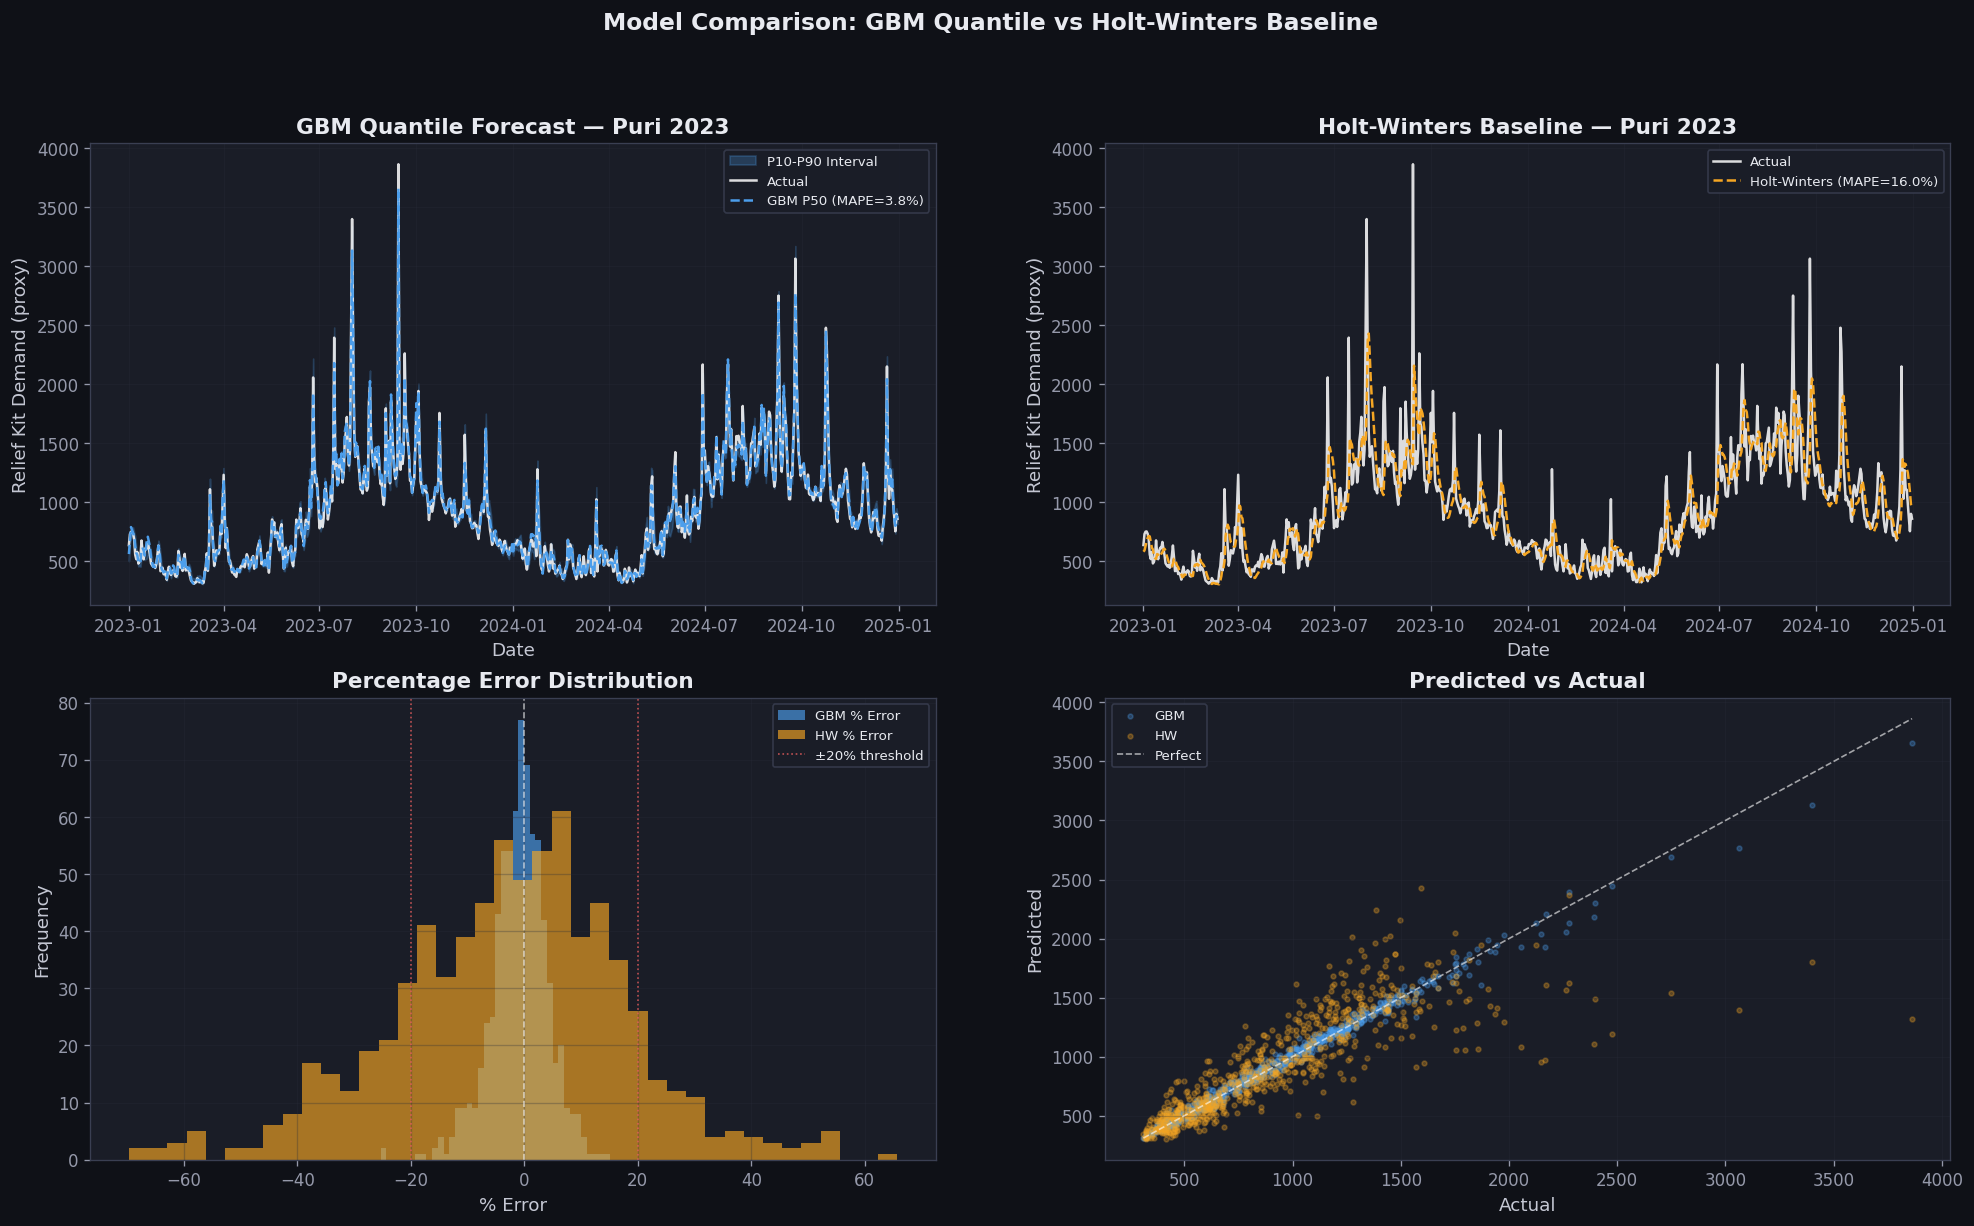

In [21]:
puri_dates_ts = pd.to_datetime(test.loc[test['district'] == 'Puri', 'date'])

fig, axes = plt.subplots(2, 2, figsize=(20, 11))
fig.patch.set_facecolor('#0F1117')

ax = axes[0, 0]
ax.fill_between(puri_dates_ts, pred_p10_puri, pred_p90_puri,
                alpha=0.25, color=ACCENT, label='P10-P90 Interval')
ax.plot(puri_dates_ts, y_puri,
        color='white', lw=1.5, alpha=0.85, label='Actual')
ax.plot(puri_dates_ts, pred_p50_puri,
        color=ACCENT, lw=1.5, linestyle='--',
        label=f'GBM P50 (MAPE={mape_gbm_puri:.1f}%)')
ax.set_title('GBM Quantile Forecast — Puri 2023', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Relief Kit Demand (proxy)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(puri_dates_ts, y_puri,
        color='white', lw=1.5, alpha=0.85, label='Actual')
ax.plot(puri_dates_ts, hw_preds,
        color=ACCENT2, lw=1.5, linestyle='--',
        label=f'Holt-Winters (MAPE={mape_hw:.1f}%)')
ax.set_title('Holt-Winters Baseline — Puri 2023', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Relief Kit Demand (proxy)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
gbm_errors = (y_puri - pred_p50_puri) / y_puri * 100
hw_errors  = (puri_test - hw_preds)   / puri_test * 100
ax.hist(gbm_errors, bins=40, alpha=0.65, color=ACCENT,  label='GBM % Error')
ax.hist(hw_errors,  bins=40, alpha=0.65, color=ACCENT2, label='HW % Error')
ax.axvline(0,   color='white', lw=1, linestyle='--', alpha=0.6)
ax.axvline(-20, color=DANGER,  lw=1, linestyle=':',  alpha=0.8,
           label='±20% threshold')
ax.axvline(+20, color=DANGER,  lw=1, linestyle=':',  alpha=0.8)
ax.set_title('Percentage Error Distribution', fontweight='bold')
ax.set_xlabel('% Error'); ax.set_ylabel('Frequency')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.scatter(y_puri,     pred_p50_puri, alpha=0.3, s=8, color=ACCENT,  label='GBM')
ax.scatter(puri_test,  hw_preds,      alpha=0.3, s=8, color=ACCENT2, label='HW')
lo = min(y_puri.min(), puri_test.min())
hi = max(y_puri.max(), puri_test.max())
ax.plot([lo, hi], [lo, hi], 'w--', lw=1, alpha=0.6, label='Perfect')
ax.set_title('Predicted vs Actual', fontweight='bold')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('Model Comparison: GBM Quantile vs Holt-Winters Baseline',
             fontsize=14, fontweight='bold')
plt.savefig('model_comparison.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


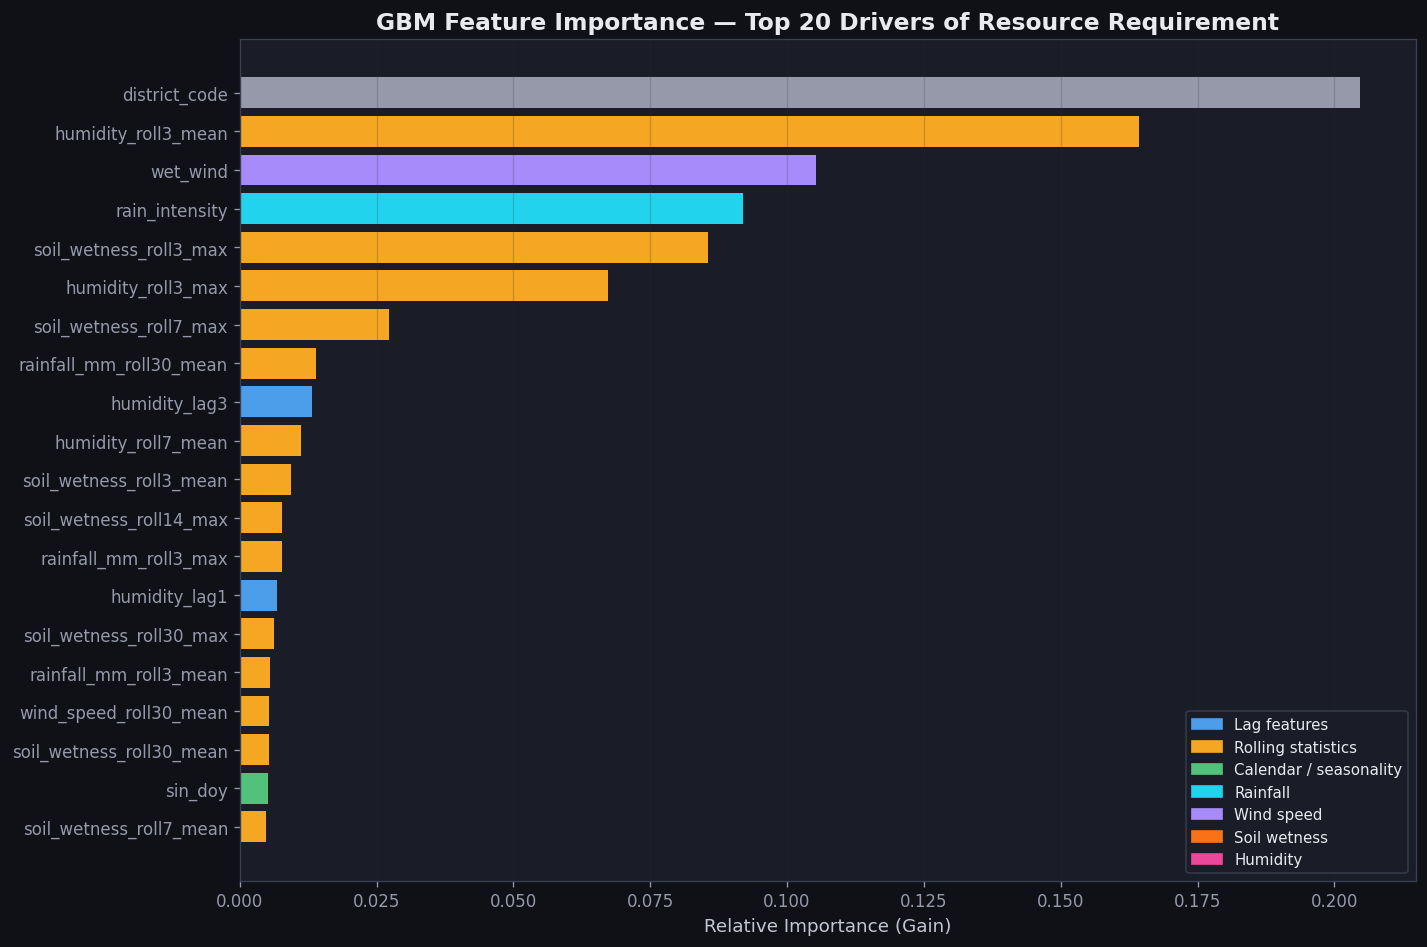

Top-5 drivers: ['district_code', 'humidity_roll3_mean', 'wet_wind', 'rain_intensity', 'soil_wetness_roll3_max']


In [22]:
importances = gbm_median.feature_importances_
fi_df = (pd.DataFrame({'Feature': FEATURE_COLS_MODEL, 'Importance': importances})
         .sort_values('Importance', ascending=True)
         .tail(20))

def fi_color(f):
    if 'lag'  in f:    return ACCENT
    if 'roll' in f:    return ACCENT2
    if any(x in f for x in ['sin','cos','month','doy','week']): return SUCCESS
    if 'rain' in f:    return CYAN
    if 'wind' in f:    return PURPLE
    if 'soil' in f:    return '#F97316'
    if 'humid' in f:   return '#EC4899'
    return '#9599AA'

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0F1117')
ax.barh(fi_df['Feature'], fi_df['Importance'],
        color=[fi_color(f) for f in fi_df['Feature']], edgecolor='none')
ax.set_title('GBM Feature Importance — Top 20 Drivers of Resource Requirement',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Relative Importance (Gain)')
ax.grid(True, alpha=0.2, axis='x')
handles = [
    mpatches.Patch(color=ACCENT,   label='Lag features'),
    mpatches.Patch(color=ACCENT2,  label='Rolling statistics'),
    mpatches.Patch(color=SUCCESS,  label='Calendar / seasonality'),
    mpatches.Patch(color=CYAN,     label='Rainfall'),
    mpatches.Patch(color=PURPLE,   label='Wind speed'),
    mpatches.Patch(color='#F97316',label='Soil wetness'),
    mpatches.Patch(color='#EC4899',label='Humidity'),
]
ax.legend(handles=handles, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Top-5 drivers:', fi_df.tail(5)['Feature'].tolist()[::-1])


In [23]:
FORECAST_HORIZON = 30
FORECAST_START   = pd.Timestamp('2025-01-01')

def project_demand(district, horizon=30):
    dist_data = (eng_data_clean[eng_data_clean['district'] == district]
                 .sort_values('date'))
    dist_code = int(dist_data['district_code'].iloc[-1])
    last = dist_data.iloc[-30:]
    weather_cols = ['rainfall_mm', 'humidity', 'wind_speed',
                    'soil_wetness', 'temperature']
    bufs = {c: list(last[c].values) for c in weather_cols}
    dates = [FORECAST_START + timedelta(days=i) for i in range(horizon)]
    p50_list, p10_list, p90_list = [], [], []

    for d in dates:
        month = d.month
        doy   = d.timetuple().tm_yday
        row = {
            'dayofyear': doy, 'month': month,
            'week': d.isocalendar()[1], 'dayofweek': d.weekday(),
            'is_monsoon': int(6 <= month <= 9),
            'sin_doy':   np.sin(2 * np.pi * doy / 365.25),
            'cos_doy':   np.cos(2 * np.pi * doy / 365.25),
            'sin_month': np.sin(2 * np.pi * month / 12),
            'cos_month': np.cos(2 * np.pi * month / 12),
            'district_code': dist_code,
        }
        cur = {c: bufs[c][-1] for c in weather_cols}
        row.update(cur)
        for c in weather_cols:
            buf = bufs[c]
            for lag in [1, 3, 7, 14, 21, 30]:
                row[f'{c}_lag{lag}'] = buf[-lag] if lag <= len(buf) else buf[0]
            for win in [3, 7, 14, 30]:
                w = buf[-win:]
                row[f'{c}_roll{win}_mean'] = np.mean(w)
                row[f'{c}_roll{win}_max']  = np.max(w)
        row['rain_7d_trend'] = (
            row['rainfall_mm_roll7_mean'] - row['rainfall_mm_roll30_mean'])
        row['wind_7d_trend'] = (
            row['wind_speed_roll7_mean']  - row['wind_speed_roll30_mean'])
        row['rain_intensity'] = cur['rainfall_mm'] * cur['wind_speed']
        row['wet_wind']       = cur['soil_wetness'] * cur['wind_speed']
        X_row = pd.DataFrame([row])[FEATURE_COLS_MODEL]
        p50 = float(np.clip(gbm_median.predict(X_row)[0], 200, 20000))
        p10 = float(np.clip(gbm_low.predict(X_row)[0],    200, 20000))
        p90 = float(np.clip(gbm_high.predict(X_row)[0],   200, 20000))
        p50_list.append(p50); p10_list.append(p10); p90_list.append(p90)
        for c in weather_cols:
            bufs[c].append(bufs[c][-1])
            bufs[c] = bufs[c][-30:]

    return dates, np.array(p50_list), np.array(p10_list), np.array(p90_list)

forecast_results = {}
for d in DISTRICTS:
    dates_f, p50, p10, p90 = project_demand(d)
    forecast_results[d] = {'dates': dates_f, 'p50': p50, 'p10': p10, 'p90': p90}

rows = []
for d in DISTRICTS:
    r    = forecast_results[d]
    peak = r['p50'].max()
    disp = peak * 5
    risk_score = min(10, peak / 500)
    risk_label = ('CRITICAL' if risk_score > 6 else
                  'HIGH'     if risk_score > 3 else 'MODERATE')
    rows.append({
        'District':         d,
        'Relief Kits':      int(peak),
        'Dry Rations (kg)': int(disp * 2.5),
        'ORS Packets':      int(disp * 10 / 7),
        'Tarpaulin Sheets': int(disp * 0.2),
        'Medical Kits':     int(disp * 0.02),
        'Risk Score':       round(risk_score, 1),
        'Risk Level':       risk_label,
    })
forecast_table = pd.DataFrame(rows).set_index('District')
print('30-Day Peak Demand Forecast Matrix:')
print(forecast_table.to_string())


30-Day Peak Demand Forecast Matrix:
               Relief Kits  Dry Rations (kg)  ORS Packets  Tarpaulin Sheets  Medical Kits  Risk Score Risk Level
District                                                                                                        
Puri                   873             10913         6236               873            87         1.7   MODERATE
Kendrapara             841             10515         6008               841            84         1.7   MODERATE
Jagatsinghpur          718              8979         5131               718            71         1.4   MODERATE
Bhadrak                789              9874         5642               789            78         1.6   MODERATE
Balasore              1173             14665         8380              1173           117         2.3   MODERATE


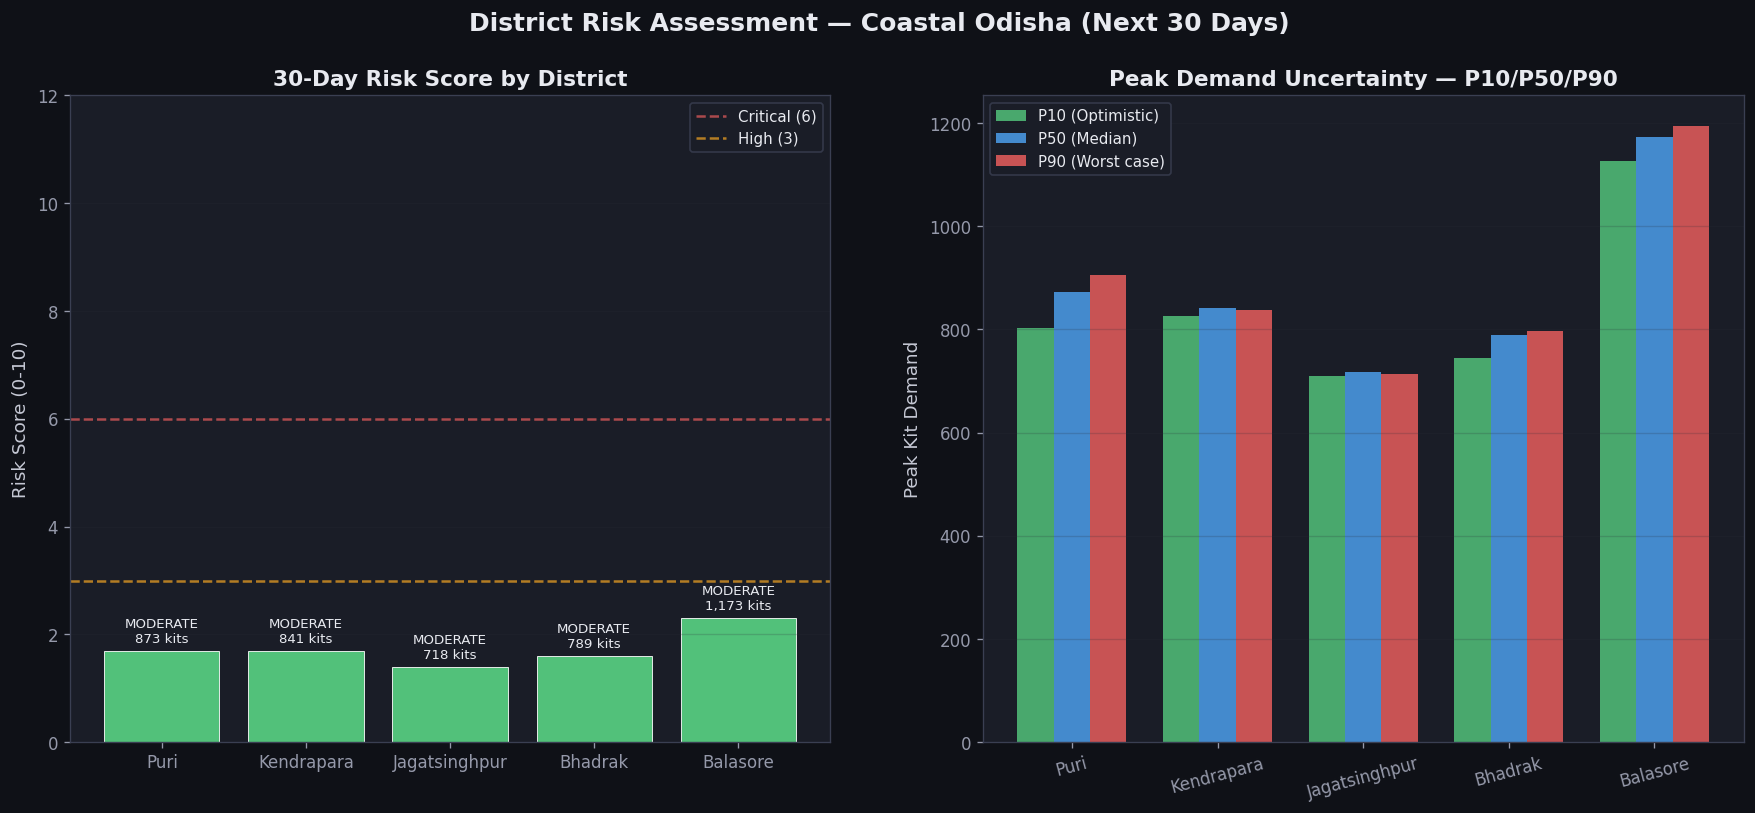

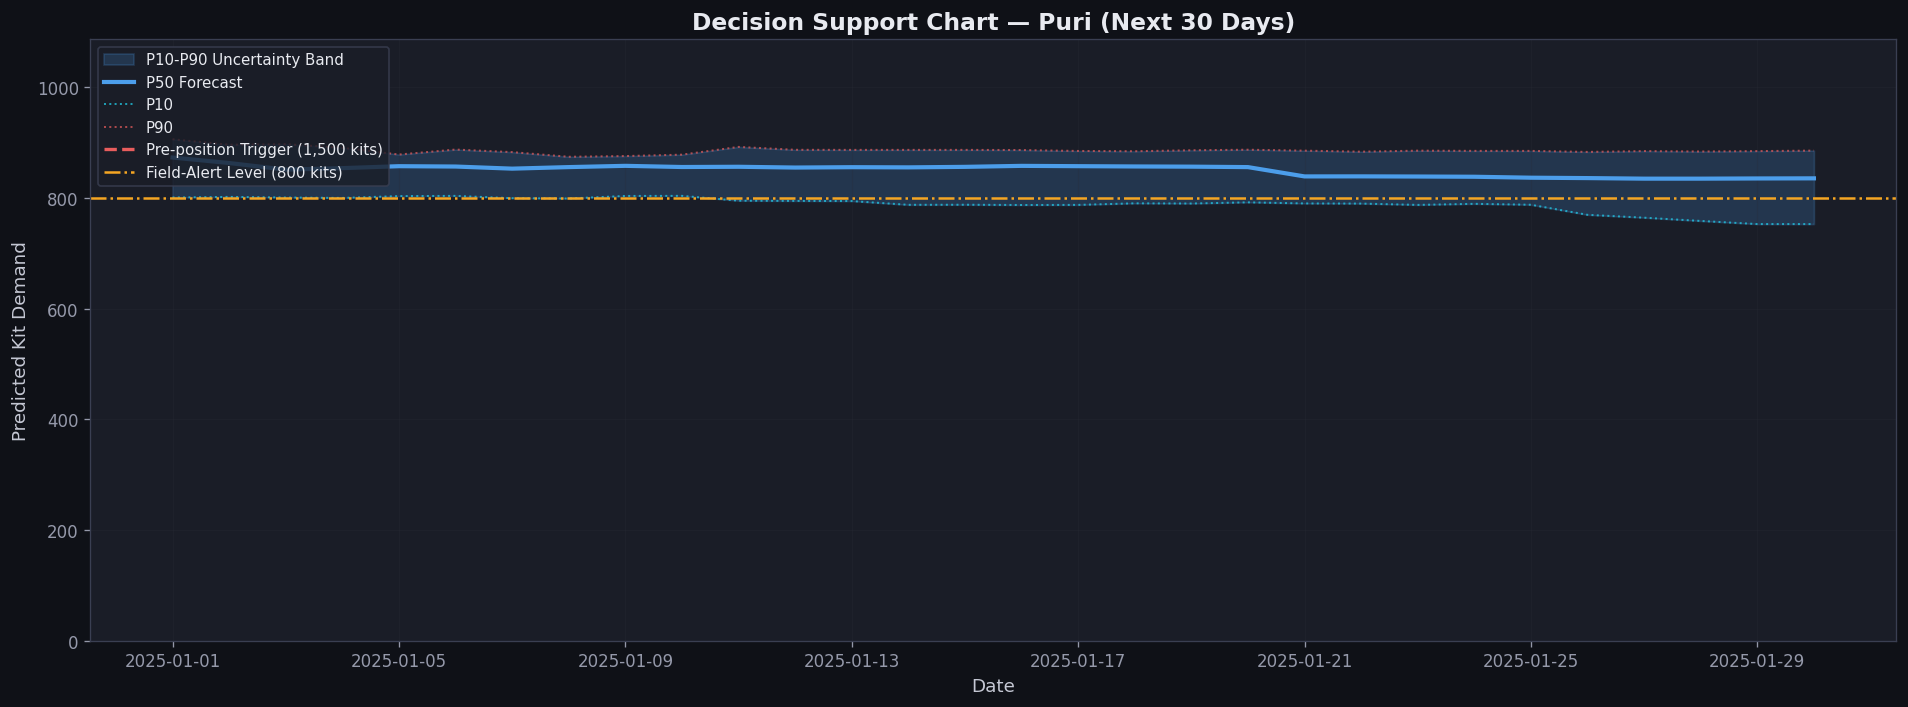

In [24]:
risk_data = []
for d in DISTRICTS:
    r = forecast_results[d]
    peak = r['p50'].max()
    risk_score = min(10, peak / 500)
    risk_label = ('CRITICAL' if risk_score > 6 else
                  'HIGH'     if risk_score > 3 else 'MODERATE')
    risk_data.append({
        'District':           d,
        'Peak Demand (Kits)': int(peak),
        'Risk Score':         round(risk_score, 1),
        'Risk Level':         risk_label,
        'P10':                int(r['p10'].max()),
        'P90':                int(r['p90'].max()),
    })
risk_df = pd.DataFrame(risk_data)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0F1117')

ax = axes[0]
colors_risk = [
    DANGER  if r == 'CRITICAL' else
    ACCENT2 if r == 'HIGH' else SUCCESS
    for r in risk_df['Risk Level']]
bars = ax.bar(risk_df['District'], risk_df['Risk Score'],
              color=colors_risk, edgecolor='white', linewidth=0.5)
ax.set_title('30-Day Risk Score by District', fontweight='bold', fontsize=13)
ax.set_ylabel('Risk Score (0-10)'); ax.set_ylim(0, 12)
ax.axhline(6, color=DANGER,  lw=1.5, linestyle='--', alpha=0.7, label='Critical (6)')
ax.axhline(3, color=ACCENT2, lw=1.5, linestyle='--', alpha=0.7, label='High (3)')
ax.grid(True, alpha=0.2, axis='y'); ax.legend(fontsize=9)
for bar, row in zip(bars, risk_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{row._4}\n{row._2:,} kits',
            ha='center', va='bottom', fontsize=8)

ax = axes[1]
x = np.arange(len(DISTRICTS)); w = 0.25
ax.bar(x - w, risk_df['P10'],                  w, label='P10 (Optimistic)',  color=SUCCESS, alpha=0.85)
ax.bar(x,     risk_df['Peak Demand (Kits)'],   w, label='P50 (Median)',      color=ACCENT,  alpha=0.85)
ax.bar(x + w, risk_df['P90'],                  w, label='P90 (Worst case)',  color=DANGER,  alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(DISTRICTS, rotation=15)
ax.set_title('Peak Demand Uncertainty — P10/P50/P90', fontweight='bold', fontsize=13)
ax.set_ylabel('Peak Kit Demand')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2, axis='y')

fig.suptitle('District Risk Assessment — Coastal Odisha (Next 30 Days)',
             fontsize=15, fontweight='bold')
plt.savefig('risk_map.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

district_focus = 'Puri'
r = forecast_results[district_focus]
dates_f, p50, p10, p90 = r['dates'], r['p50'], r['p10'], r['p90']
trigger_days  = [i for i in range(len(p50)) if p50[i] > SPHERE_THRESHOLD]
first_trigger = trigger_days[0] if trigger_days else None
if first_trigger:
    recommend_date = (
        dates_f[first_trigger] - timedelta(days=2)).strftime('%d %b %Y')
    action = 'RECOMMEND PRE-POSITION NOW'
else:
    recommend_date = 'N/A'
    action = 'ROUTINE MONITORING'

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0F1117')
ax.fill_between(dates_f, p10, p90, alpha=0.20, color=ACCENT,
                label='P10-P90 Uncertainty Band')
ax.plot(dates_f, p50,  color=ACCENT, lw=2.5,  label='P50 Forecast', zorder=5)
ax.plot(dates_f, p10,  color=CYAN,   lw=1.2, linestyle=':', alpha=0.7, label='P10')
ax.plot(dates_f, p90,  color=DANGER, lw=1.2, linestyle=':', alpha=0.7, label='P90')
ax.axhline(SPHERE_THRESHOLD, color=DANGER, lw=2, linestyle='--',
           label=f'Pre-position Trigger ({SPHERE_THRESHOLD:,} kits)')
ax.axhline(ALERT_THRESHOLD, color=ACCENT2, lw=1.5, linestyle='-.',
           label=f'Field-Alert Level ({ALERT_THRESHOLD:,} kits)')
if first_trigger:
    td = dates_f[first_trigger]
    ax.axvline(td, color=DANGER, lw=2, alpha=0.8)
    ax.fill_betweenx([0, p90.max() * 1.15],
                     td - timedelta(days=2), td,
                     alpha=0.15, color=DANGER, label='48-hr Pre-position Window')
    ax.text(td, p90.max() * 1.02,
            f' TRIGGER\n {td.strftime("%d %b")}',
            color=DANGER, fontsize=11, fontweight='bold', va='top')
ax.set_title(f'Decision Support Chart — {district_focus} (Next 30 Days)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Date'); ax.set_ylabel('Predicted Kit Demand')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.25); ax.set_ylim(0, p90.max() * 1.2)
plt.tight_layout()
plt.savefig('decision_support.png', bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


## Decision-Support Summary

### Operational Workflow

| Day | Trigger | Action |
|-----|---------|--------|
| T-7 | Demand spike >20% above 30-day baseline | Activate district coordinator network |
| T-5 | P90 forecast crosses 1,500 kits | Emergency procurement order |
| T-3 | Alert level upgrades | Confirm vendor contracts; book last-mile transport |
| T-48h | P50 sustains above trigger for 2+ days | **DEPLOY** to district hubs |
| T+0 | Flood peak | On-ground distribution; collect actuals for retraining |

### Decision Matrix

| Forecast Signal | Alert | Action |
|:---|:---|:---|
| P50 < 800 kits/day | Green | Routine monitoring |
| P50 800–1,500 kits/day | Yellow | Alert field teams; check inventory |
| P50 > 1,500 (P90 > 3,000) | Orange | Emergency procurement begins |
| P50 > 3,000 | Red | Immediate pre-position + mutual-aid |

### SPHERE Supply Norms per 1,000 Displaced Persons (7-Day Stockpile)

| Resource | 7-Day (1,000 displaced) |
|:---|:---|
| Dry Rations | 17,500 kg |
| Drinking Water | 105,000 L |
| Tarpaulin | 200 sheets |
| ORS Packets | 10,000 packets |
| Medical Kits | 20 kits |

*Data: NASA POWER MERRA-2 · Model: GBM Quantile Regression · Norms: SPHERE Handbook 2018*


In [25]:
highest = risk_df.loc[risk_df["Risk Score"].idxmax()]
lowest = risk_df.loc[risk_df["Risk Score"].idxmin()]

print("Highest Risk District:", highest["District"])
print("Lowest Risk District:", lowest["District"])
print("Average Risk Score:", round(risk_df["Risk Score"].mean(), 2))

priority = risk_df[
    risk_df["Risk Score"] >= risk_df["Risk Score"].median()
]

print("\nPriority Districts:")
for d in priority["District"]:
    print("-", d)

Highest Risk District: Balasore
Lowest Risk District: Jagatsinghpur
Average Risk Score: 1.74

Priority Districts:
- Puri
- Kendrapara
- Balasore
